In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shauryasrivastava01/fertility-health-dataset/fertility_health_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import xgboost as xgb

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/shauryasrivastava01/fertility-health-dataset/fertility_health_dataset.csv")
df.head()

,Couple_ID,Female_Age,Male_Age,Female_BMI,Male_BMI,PCOS,Period_Regularity,Stress_Level,Sleep_Quality,Past_Pregnancies,Sperm_Count_M_per_mL,Sperm_Motility_Pct,Female_Smokes,Male_Smokes,Female_Alcohol,Male_Alcohol,Female_Exercise,Male_Exercise,Pregnancy_Success
0,CPL0001,26,28,21.1,30.1,No,Regular,5.4,6.1,1,21.6,81.0,No,Yes,Moderate,No_Alcohol,Light,No_Exercise,Failure
1,CPL0002,39,43,24.1,24.6,No,Regular,2.1,5.6,0,41.5,56.8,No,No,Low,High,Light,Active,Failure
2,CPL0003,34,41,25.4,25.9,Yes,Irregular,5.8,5.1,3,64.5,50.8,No,No,No_Alcohol,No_Alcohol,Light,No_Exercise,Success
3,CPL0004,30,33,28.7,30.1,No,Regular,7.2,4.9,2,80.2,46.6,No,No,Moderate,No_Alcohol,No_Exercise,Active,Success
4,CPL0005,27,31,25.1,22.7,Yes,Irregular,6.3,5.3,3,97.2,53.1,No,Yes,Low,Low,Active,Moderate,Failure


In [4]:
# Drop ID
df = df.drop(columns=["Couple_ID"])

# Binary mapping
binary_map = {"Yes":1, "No":0, "Success":1, "Failure":0}

for col in ["PCOS","Female_Smokes","Male_Smokes","Pregnancy_Success"]:
    df[col] = df[col].map(binary_map)

# Encode categories
cat_cols = ["Period_Regularity","Female_Alcohol","Male_Alcohol","Female_Exercise","Male_Exercise"]

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

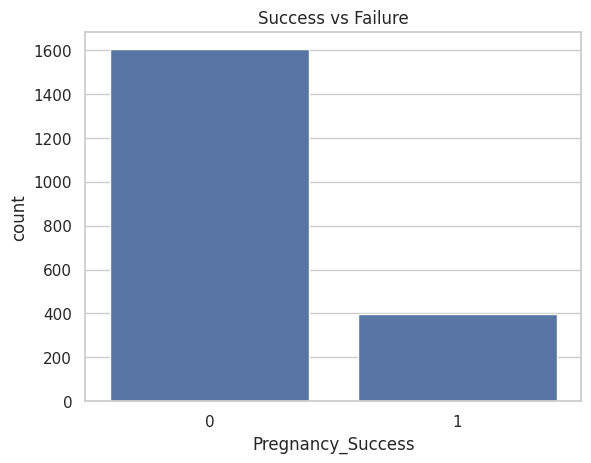

In [5]:
sns.countplot(x="Pregnancy_Success", data=df)
plt.title("Success vs Failure")
plt.show()

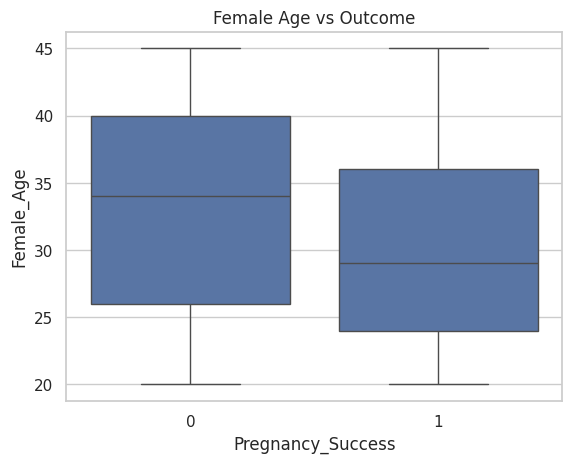

In [6]:
sns.boxplot(x="Pregnancy_Success", y="Female_Age", data=df)
plt.title("Female Age vs Outcome")
plt.show()

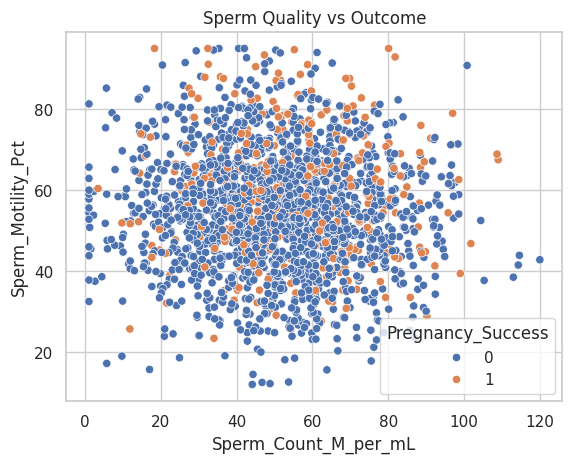

In [7]:
sns.scatterplot(
    x="Sperm_Count_M_per_mL",
    y="Sperm_Motility_Pct",
    hue="Pregnancy_Success",
    data=df
)
plt.title("Sperm Quality vs Outcome")
plt.show()

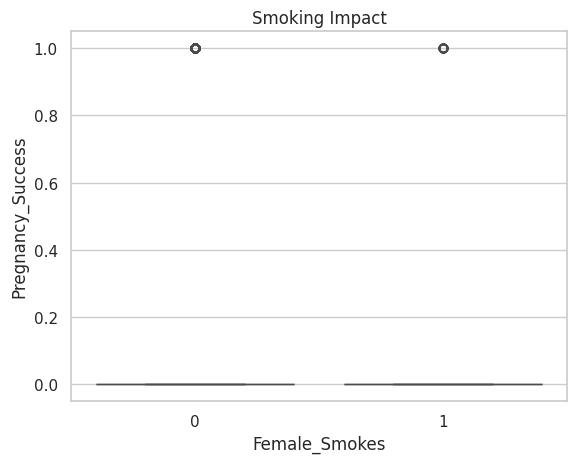

In [8]:
sns.boxplot(x="Female_Smokes", y="Pregnancy_Success", data=df)
plt.title("Smoking Impact")
plt.show()

In [9]:
X = df.drop(columns=["Pregnancy_Success"])
y = df["Pregnancy_Success"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = xgb.XGBClassifier(n_estimators=300)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.7625
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       326
           1       0.20      0.09      0.13        74

    accuracy                           0.76       400
   macro avg       0.51      0.50      0.50       400
weighted avg       0.70      0.76      0.73       400



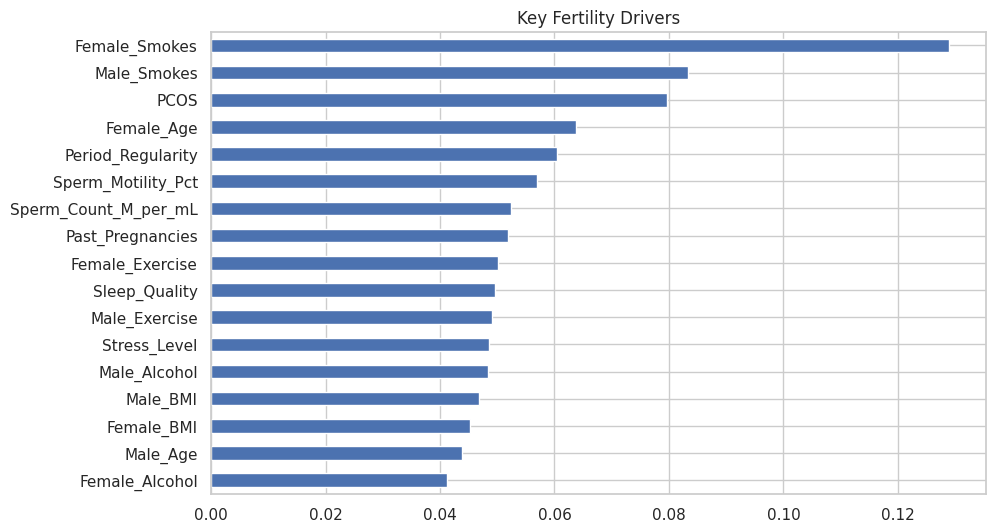

In [10]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Key Fertility Drivers")
plt.show()

In [11]:
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4)
df["cluster"] = kmeans.fit_predict(scaled)

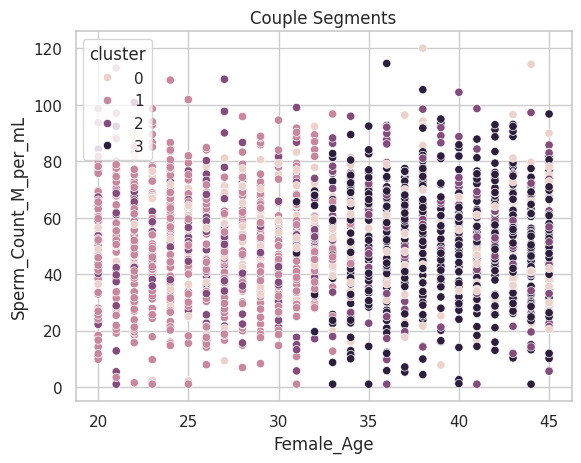

In [12]:
sns.scatterplot(
    x="Female_Age",
    y="Sperm_Count_M_per_mL",
    hue="cluster",
    data=df
)
plt.title("Couple Segments")
plt.show()

In [13]:
success_df = df[df["Pregnancy_Success"] == 1]

print(success_df.mean())

Female_Age              30.404040
Male_Age                33.744949
Female_BMI              23.784091
Male_BMI                25.808586
PCOS                     0.118687
Period_Regularity        0.790404
Stress_Level             4.653535
Sleep_Quality            6.798232
Past_Pregnancies         0.795455
Sperm_Count_M_per_mL    54.307828
Sperm_Motility_Pct      59.300000
Female_Smokes            0.111111
Male_Smokes              0.156566
Female_Alcohol           2.138889
Male_Alcohol             1.977273
Female_Exercise          1.568182
Male_Exercise            1.553030
Pregnancy_Success        1.000000
cluster                  1.578283
dtype: float64


In [14]:
def predict_success(input_dict):
    input_df = pd.DataFrame([input_dict])
    prob = model.predict_proba(input_df)[0][1]
    return prob

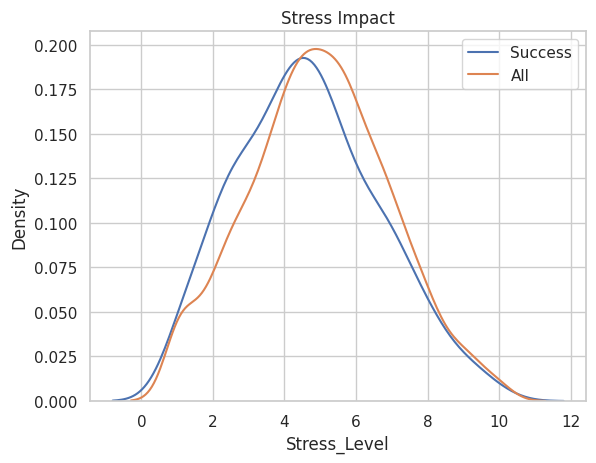

In [15]:
sns.kdeplot(success_df["Stress_Level"], label="Success")
sns.kdeplot(df["Stress_Level"], label="All")
plt.legend()
plt.title("Stress Impact")
plt.show()